# 0. Initialization

In [1]:
!python -m ensurepip --upgrade
!python -m pip install pandas numpy openpyxl matplotlib

Looking in links: /tmp/tmp2ekpckmj

[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip


In [2]:
import os
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [3]:
def search_df(df, *substrings):
    """Display rows containing all requested substrings so source-table issues can be inspected quickly."""
    for s in substrings:
        df = df[df.apply(lambda row, s=s: row.astype(str).str.contains(s).any(), axis=1)]
    display(df)

In [4]:
DATA_PATH = Path("/mnt/data/MOU/breast/mammaprint/")

DATA_FILES = [
    DATA_PATH / "data_2023-09-25.xlsx",
    DATA_PATH / "data_test_set_2024-02-16.xlsx",
    DATA_PATH / "data-dodatek-2023-10-19.xlsx",
    DATA_PATH / "Mammaprint-surova data.xlsx",
    DATA_PATH / "Soubor RNA Mammaprint-1_10_25_pro AI.xlsx",
    DATA_PATH / "Mammaprint_anonymizovany.xlsx"
    
]

VALID_TYPES = ["a luminal", "b luminal"]
INDEX_PATTERN = re.compile(r"^(\d{4})/\s*(\d{1,5})(?:-(\d))?$")
FILENAME_PATTERN = re.compile(r"^(P?)(\d{4})_(\d{1,5})(?:-(\d))?$")


COLUMN_MAPPING = {
    "číslo záznamu": "record_num",
    "mammaprint index": "mammaprint_index",
    "typ": "type",
}
NON_MAPPING_COLS = ["source_table", "original_index"]

In [ ]:
INDICES_MAPPING = {
    "2023/3222 a": "2023/03222",
    "2023/3222 b": "2023/03222",
    "2024/2324ii": "2024/02324-2",
    "2023/3206 ii": "2023/03206",
}
FILES_MAPPING = {
    "P2023_03525-35": "P2023_03525-1",
    "P2023_03525-23": "P2023_03525-2",
    "P2025_00968": "P2025_00968-1",
}

# record_num
DROP_ROWS = [
    # tbd with doctor
]

RECORD_NUM_CORRECTIONS = [
    {
        "source_table": "Mammaprint-surova data:2023",
        "original_record_num": "2023/3525",
        "mammaprint_index": 0.235,
        "type": "a luminal",
        "corrected_record_num": "2023/03525-1",
    },
    {
        "source_table": "Mammaprint-surova data:2023",
        "original_record_num": "2023/3525",
        "mammaprint_index": -0.345,
        "type": "b luminal",
        "corrected_record_num": "2023/03525-2",
    },
    {
        "source_table": "data_test_set_2024-02-16:List1",
        "original_record_num": "2023/03525",
        "mammaprint_index": 0.235,
        "type": "a luminal",
        "corrected_record_num": "2023/03525-1",
    },
    {
        "source_table": "data_test_set_2024-02-16:List1",
        "original_record_num": "2023/03525",
        "mammaprint_index": -0.345,
        "type": "b luminal",
        "corrected_record_num": "2023/03525-2",
    },
    {
        "source_table": "Mammaprint_anonymizovany:2023",
        "original_record_num": "2023/3525",
        "mammaprint_index": 0.235,
        "type": "a luminal",
        "corrected_record_num": "2023/03525-1",
    },
    {
        "source_table": "Mammaprint_anonymizovany:2023",
        "original_record_num": "2023/3525",
        "mammaprint_index": -0.345,
        "type": "b luminal",
        "corrected_record_num": "2023/03525-2",
    },
    {
        "source_table": "Soubor RNA Mammaprint-1_10_25_pro AI:2025",
        "original_record_num": "2025/968a",
        "mammaprint_index": 0.541,
        "type": "a luminal",
        "corrected_record_num": "2025/00968-1",
    },
    {
        "source_table": "Soubor RNA Mammaprint-1_10_25_pro AI:2025",
        "original_record_num": "2025/968b",
        "mammaprint_index": -0.076,
        "type": "b luminal",
        "corrected_record_num": "2025/00968-2",
    },
    {
        "source_table": "Mammaprint_anonymizovany:2025",
        "original_record_num": "2025/968a",
        "mammaprint_index": 0.541,
        "type": "a luminal",
        "corrected_record_num": "2025/00968-1",
    },
    {
        "source_table": "Mammaprint_anonymizovany:2025",
        "original_record_num": "2025/968b",
        "mammaprint_index": -0.076,
        "type": "b luminal",
        "corrected_record_num": "2025/00968-2",
    },
]

# Part 1: Table Loading & Merging

In [6]:
def normalize_excel_text(value):
    """Normalize raw Excel text so header and value comparisons are consistent across files."""
    if isinstance(value, str):
        return value.replace("\n", " ").strip().lower()
    return value


def normalize_excel_frame(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize all cell text and column names so downstream mapping sees one canonical format."""
    df = df.map(normalize_excel_text)
    df.columns = df.columns.map(normalize_excel_text)
    return df


def find_header_row(raw: pd.DataFrame) -> int | None:
    """Find the real table header row because source spreadsheets start at different offsets."""
    normalized = raw.map(normalize_excel_text)

    for i, row in normalized.iterrows():
        row_values = row.tolist()
        if (
            "číslo záznamu" in row_values
            and "mammaprint index" in row_values
            and "typ" in row_values
        ):
            return i

    return None


def _matches_correction_value(series: pd.Series, expected):
    """Compare correction selectors robustly so known fixes match exactly one intended row."""
    if isinstance(expected, float):
        values = pd.to_numeric(series, errors="coerce")
        return (values - expected).abs() <= 1e-9
    return series.astype(str).str.strip().str.lower() == str(expected).strip().lower()


def apply_record_num_corrections(
    df: pd.DataFrame, path: Path, sheet_name: str
) -> pd.DataFrame:
    """Apply hand-verified record number fixes so ambiguous duplicate entries keep distinct IDs."""
    source_table = f"{Path(path).stem}:{sheet_name}"
    record_col = "číslo záznamu" if "číslo záznamu" in df.columns else df.columns[0]
    corrections = [
        correction
        for correction in RECORD_NUM_CORRECTIONS
        if correction["source_table"] == source_table
    ]

    for correction in corrections:
        mask = _matches_correction_value(
            df[record_col], correction["original_record_num"]
        )
        mask &= _matches_correction_value(
            df["mammaprint index"], correction["mammaprint_index"]
        )
        mask &= _matches_correction_value(df["typ"], correction["type"])

        matches = df.index[mask].tolist()
        if len(matches) != 1:
            raise ValueError(
                f"Expected exactly one row for record correction {correction}, "
                f"found {len(matches)}"
            )

        df.loc[matches[0], record_col] = correction["corrected_record_num"]

    return df


In [7]:
def read_diverse_excel(path: Path, sheet_name: str):
    """Load one heterogeneous Excel sheet into a normalized table for merging with other sources."""
    # Step 1: read without a header so we can inspect candidate header rows
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Step 2: find the real header row using normalized candidate rows
    header_row = find_header_row(raw)

    # Step 3: load/build the dataframe using the detected header
    if header_row is not None:
        df = pd.read_excel(path, sheet_name=sheet_name, header=header_row)
    else:
        # no header found -> assume first three columns correspond to the expected fields
        df = raw.copy()
        expected_cols = ["číslo záznamu", "mammaprint index", "typ"]
        rest_cols = [f"col_{i}" for i in range(df.shape[1] - 3)]
        df.columns = expected_cols + rest_cols

    # Step 4: normalize columns and string cells after the table shape is known
    df = normalize_excel_frame(df)

    # Step 5: apply known record-number fixes, then normalize inserted values
    df = apply_record_num_corrections(df, path, sheet_name)
    df = normalize_excel_frame(df)

    # Step 6: backfill repeated-table IDs and continue with common cleanup
    df.iloc[:, 0] = df.iloc[:, 0].ffill()  # use id of previous entry
    df = df.dropna(how="all")

    df["source_table"] = f"{Path(path).stem}:{sheet_name}"
    df["original_index"] = df.iloc[:, 0].copy()

    return df


In [8]:
all_dfs = []

for file in DATA_FILES:
    print(f"Reading {file}...")
    excel_file = pd.ExcelFile(file)

    for sheet_name in excel_file.sheet_names:
        df = read_diverse_excel(file, sheet_name)
        print(f"  - Sheet '{sheet_name}': {len(df)} rows")
        all_dfs.append(df)

merged_df = pd.concat(all_dfs, ignore_index=True).drop_duplicates()
print(f"\nTotal rows: {len(merged_df)}")

Reading /mnt/data/MOU/breast/mammaprint/data_2023-09-25.xlsx...
  - Sheet 'List1': 263 rows
Reading /mnt/data/MOU/breast/mammaprint/data_test_set_2024-02-16.xlsx...
  - Sheet 'List1': 204 rows
Reading /mnt/data/MOU/breast/mammaprint/data-dodatek-2023-10-19.xlsx...
  - Sheet 'List1': 37 rows
Reading /mnt/data/MOU/breast/mammaprint/Mammaprint-surova data.xlsx...
  - Sheet '2024': 602 rows
  - Sheet '2023': 417 rows
Reading /mnt/data/MOU/breast/mammaprint/Soubor RNA Mammaprint-1_10_25_pro AI.xlsx...
  - Sheet '2025': 697 rows
Reading /mnt/data/MOU/breast/mammaprint/Mammaprint_anonymizovany.xlsx...
  - Sheet '2026': 184 rows
  - Sheet '2025': 871 rows
  - Sheet '2024': 760 rows
  - Sheet '2023': 419 rows

Total rows: 4444


### Modify columns
- rename columns
- join data in unnamed columns into one called `note`

In [9]:
mapped_cols = {}

for col in merged_df.columns:
    col_lower = col.lower().strip()
    for source_name, target_name in COLUMN_MAPPING.items():
        if col_lower == source_name.lower():
            mapped_cols[col] = target_name
            break

print(f"Mapped columns: {mapped_cols}")

Mapped columns: {'číslo záznamu': 'record_num', 'mammaprint index': 'mammaprint_index', 'typ': 'type'}


In [10]:
result_df = pd.DataFrame()

for source_col, target_col in mapped_cols.items():
    result_df[target_col] = merged_df[source_col]

result_df[NON_MAPPING_COLS] = merged_df[NON_MAPPING_COLS]
other_cols = [
    col
    for col in merged_df.columns
    if col not in mapped_cols and col not in NON_MAPPING_COLS
]


def merge_columns_to_note(row):
    """Collect non-mapping source columns into a note so useful audit context is not lost."""
    notes = []
    for col in other_cols:
        value = row[col]
        if pd.notna(value) and str(value).strip() != "":
            notes.append(f"{col}: {value}")
    return "; ".join(notes) if notes else ""


result_df["note"] = merged_df.apply(merge_columns_to_note, axis=1)

print(f"\nResult dataframe: {len(result_df)} rows, {len(result_df.columns)} columns")


Result dataframe: 4444 rows, 6 columns


# Part 2: Table data quality

In [11]:
def add_entry_quality_flag(df, invalid, flag):
    """Append a quality flag to invalid rows so multiple issues can be tracked per entry."""
    def append_flag(current):
        if current == "OK" or pd.isna(current):
            return flag
        flags = str(current).split(";")
        if flag in flags:
            return current
        return ";".join(flags + [flag])

    df.loc[invalid, "entry_quality"] = df.loc[invalid, "entry_quality"].apply(
        append_flag
    )


def has_entry_quality_flag(series, flag):
    """Check semicolon-delimited quality flags so later steps can skip known-bad rows."""
    return series.astype(str).str.split(";").apply(lambda flags: flag in flags)


def validate_mammaprint_index(df):
    """Flag invalid Mammaprint values so only numeric scores in the expected range pass."""
    mammaprint_values = pd.to_numeric(df["mammaprint_index"], errors="coerce")
    invalid = (
        mammaprint_values.isna() | (mammaprint_values < -1) | (mammaprint_values > 1)
    )
    add_entry_quality_flag(df, invalid, "MAMMAPRINT")


def validate_type(df):
    """Flag invalid luminal types so downstream labels use the supported class names only."""
    invalid = df["type"].isna() | ~df["type"].astype(str).str.strip().isin(VALID_TYPES)
    add_entry_quality_flag(df, invalid, "TYPE")


def validate_luminal_interval(df):
    """Flag type-score disagreements so A/B luminal labels match the Mammaprint sign."""
    mammaprint_values = pd.to_numeric(df["mammaprint_index"], errors="coerce")
    normalized_type = df["type"].astype(str).str.strip().str.lower()

    invalid_a = (
        normalized_type.eq("a luminal")
        & mammaprint_values.notna()
        & ~((mammaprint_values > 0) & (mammaprint_values <= 1))
    )
    invalid_b = (
        normalized_type.eq("b luminal")
        & mammaprint_values.notna()
        & ~((mammaprint_values >= -1) & (mammaprint_values < 0))
    )

    add_entry_quality_flag(df, invalid_a | invalid_b, "LUMINAL_INTERVAL")


def validate_record_num(df):
    """Flag malformed record numbers before normalization so unexpected IDs are reviewed."""
    invalid = df["record_num"].isna() | (
        ~df["record_num"]
        .astype(str)
        .str.fullmatch(INDEX_PATTERN)  # doesn't match regex
        & ~df["record_num"].astype(str).isin(INDICES_MAPPING.keys())  # not in dict keys
    )
    add_entry_quality_flag(df, invalid, "RECORD_NUM")

In [12]:
result_df["entry_quality"] = "OK"
validate_mammaprint_index(result_df)
validate_type(result_df)
validate_luminal_interval(result_df)
validate_record_num(result_df)

### Preprocessing

In [13]:
def normalize_index(idx: str) -> str:
    """Canonicalize record numbers so table entries and slide filenames compare reliably."""
    if idx in INDICES_MAPPING:
        return INDICES_MAPPING[idx]

    match = INDEX_PATTERN.match(idx)

    if match:
        year, num, rank = match.groups()
        num_padded = num.zfill(5)  # pad middle to 5 digits
        if rank:
            return f"{year}/{num_padded}-{rank}"
        else:
            return f"{year}/{num_padded}"
    else:
        raise ValueError(f"Flagged (unexpected format or suffix): '{idx}'")


def normalize_indices(result_df):
    """Normalize only valid record numbers so invalid rows stay visible for quality review."""
    valid_record_num = ~has_entry_quality_flag(result_df["entry_quality"], "RECORD_NUM")
    result_df.loc[valid_record_num, "record_num"] = result_df.loc[
        valid_record_num, "record_num"
    ].apply(normalize_index)


def flag_conflicting_records(result_df):
    """Mark duplicate OK records as conflicts while keeping retry/non-final rows separate."""
    conflicting_records = []
    grouped = result_df.groupby("record_num")

    for record_num, group in grouped:
        if len(group) == 1:  # just one entry, correct
            continue

        if (
            group["entry_quality"] == "OK"
        ).sum() == 0:  # no OK entry, nothing to flag further
            continue

        elif (
            group["entry_quality"] == "OK"
        ).sum() == 1:  # one OK entry (retry), others non-needed
            result_df.loc[
                (result_df["record_num"] == record_num)
                & (result_df["entry_quality"] != "OK"),
                "entry_quality",
            ] = "NON-FINAL"

        elif (
            group["entry_quality"] == "OK"
        ).sum() >= 2:  # multiple OK entries per one id, conflict
            conflicting_records.append(record_num)
            result_df.loc[result_df["record_num"] == record_num, "entry_quality"] = (
                "CONFLICT"
            )

    print(f"Conflicting record_nums: {len(conflicting_records)}")

In [14]:
normalize_indices(result_df)
result_df = result_df.drop_duplicates(
    subset=["record_num", "type", "mammaprint_index", "entry_quality"]
)
flag_conflicting_records(result_df)

Conflicting record_nums: 0


In [15]:
def record_num_stem(record_num):
    """Return the year/number stem without rank so related ranked records can be inspected together."""
    match = INDEX_PATTERN.match(str(record_num))
    if not match:
        return pd.NA

    year, num, _rank = match.groups()
    return f"{year}/{num.zfill(5)}"


valid_record_num = ~has_entry_quality_flag(result_df["entry_quality"], "RECORD_NUM")
record_stem_debug_df = result_df[valid_record_num].copy()
record_stem_debug_df["record_num_stem"] = record_stem_debug_df["record_num"].apply(
    record_num_stem
)

same_stem_counts = record_stem_debug_df.groupby("record_num_stem")[
    "record_num"
].nunique()
same_stem_stems = same_stem_counts[same_stem_counts > 1].index
same_stem_records_df = record_stem_debug_df[
    record_stem_debug_df["record_num_stem"].isin(same_stem_stems)
].sort_values(["record_num_stem", "record_num", "source_table", "original_index"])

same_stem_summary_df = same_stem_records_df.groupby("record_num_stem").agg(
    record_nums=("record_num", lambda values: sorted(values.unique())),
    row_count=("record_num", "size"),
    source_tables=("source_table", lambda values: sorted(values.unique())),
    entry_quality=("entry_quality", lambda values: sorted(values.unique())),
)

print(f"Record stems with multiple record_nums: {len(same_stem_summary_df)}")
display(same_stem_summary_df)

Record stems with multiple record_nums: 4


,record_nums,row_count,source_tables,entry_quality
record_num_stem,,,,
2023/00946,"[2023/00946, 2023/00946-2]",4,"[Mammaprint-surova data:2023, data_2023-09-25:...","[NON-FINAL, OK]"
2023/03525,"[2023/03525-1, 2023/03525-2]",2,[data_test_set_2024-02-16:List1],[OK]
2024/02324,"[2024/02324, 2024/02324-2]",2,[Mammaprint-surova data:2024],[MAMMAPRINT;TYPE]
2025/00968,"[2025/00968-1, 2025/00968-2]",2,[Soubor RNA Mammaprint-1_10_25_pro AI:2025],[OK]


### Table quality results

In [16]:
print("\n=== Quality Summary ===")
counts = result_df["entry_quality"].value_counts()

for label, count in counts.items():
    pct = count / len(result_df) * 100
    print(f"{label}: {count} rows ({pct:.1f}%)")

print(f"Total: {len(result_df)} rows\n")


for label in counts.keys():
    if label == "OK":
        continue

    # TODO non final print aj hodnotu co nasleduje
    print(f"=== {label} ===")
    display(result_df[result_df["entry_quality"] == label].head(10))
    
    # # Save to CSV
    # temp = result_df[result_df["entry_quality"] == label]
    # safe_label = label.replace(";", "_").replace("/", "_")
    # output_file = DATA_PATH / ("entry_quality_" + safe_label + ".csv")
    # temp.to_csv(output_file, index=False, encoding="utf-8")
    
    print("\n\n")


=== Quality Summary ===
OK: 2084 rows (90.5%)
NON-FINAL: 114 rows (5.0%)
MAMMAPRINT;TYPE: 89 rows (3.9%)
TYPE: 14 rows (0.6%)
MAMMAPRINT;TYPE;RECORD_NUM: 1 rows (0.0%)
LUMINAL_INTERVAL: 1 rows (0.0%)
Total: 2303 rows

=== NON-FINAL ===


,record_num,mammaprint_index,type,source_table,original_index,note,entry_quality
11,2023/00946,nelze,NaN,data_2023-09-25:List1,2023/946,,NON-FINAL
29,2023/01108,nelze,b luminal,data_2023-09-25:List1,2023/1108,,NON-FINAL
47,2023/01237,nelze,NaN,data_2023-09-25:List1,2023/1237,,NON-FINAL
56,2023/01294,nelze,NaN,data_2023-09-25:List1,2023/1294,,NON-FINAL
77,2023/01462,nelze,NaN,data_2023-09-25:List1,2023/1462,,NON-FINAL
85,2023/01486,nelze,a luminal,data_2023-09-25:List1,2023/1486,,NON-FINAL
89,2023/01591,nevyšetřeno,NaN,data_2023-09-25:List1,2023/1591,,NON-FINAL
91,2023/01597,nelze,a luminal,data_2023-09-25:List1,2023/1597,,NON-FINAL
93,2023/01599,nelze,b luminal,data_2023-09-25:List1,2023/1599,,NON-FINAL
163,2023/02298,nelze,NaN,data_2023-09-25:List1,2023/2298,,NON-FINAL





=== MAMMAPRINT;TYPE ===


,record_num,mammaprint_index,type,source_table,original_index,note,entry_quality
33,2023/01141,nelze,NaN,data_2023-09-25:List1,2023/1141,,MAMMAPRINT;TYPE
53,2023/01268,nevyšetřeno,NaN,data_2023-09-25:List1,2023/1268,,MAMMAPRINT;TYPE
61,2023/01332,nevyšetřeno,NaN,data_2023-09-25:List1,2023/1332,,MAMMAPRINT;TYPE
82,2023/01473,nevyšetřeno,NaN,data_2023-09-25:List1,2023/1473,,MAMMAPRINT;TYPE
144,2023/02114,nelze,NaN,data_2023-09-25:List1,2023/2114,,MAMMAPRINT;TYPE
145,2023/02114,specialista,NaN,data_2023-09-25:List1,2023/2114,,MAMMAPRINT;TYPE
146,2023/02114,NaN,NaN,data_2023-09-25:List1,2023/2114,,MAMMAPRINT;TYPE
170,2023/02353,nelze,NaN,data_2023-09-25:List1,2023/2353,,MAMMAPRINT;TYPE
172,2023/02353,specialista,NaN,data_2023-09-25:List1,2023/2353,,MAMMAPRINT;TYPE
173,2023/02353,9,NaN,data_2023-09-25:List1,2023/2353,,MAMMAPRINT;TYPE





=== TYPE ===


,record_num,mammaprint_index,type,source_table,original_index,note,entry_quality
369,2023/04116,-0.841,basal type,data_test_set_2024-02-16:List1,2023/04116,unnamed: 3: výsledek z agendie,TYPE
606,2024/00783,-1,bazal type,Mammaprint-surova data:2024,2024/783,,TYPE
640,2024/01000,-1,bazal type,Mammaprint-surova data:2024,2024/1000,,TYPE
1583,2025/00341,-0.792,basal type,Soubor RNA Mammaprint-1_10_25_pro AI:2025,2025/341,podíl nádorových buněk: 0.7,TYPE
1658,2025/00858,-0.115,her2,Soubor RNA Mammaprint-1_10_25_pro AI:2025,2025/858,podíl nádorových buněk: cca 15%,TYPE
1794,2025/01756,-1,bazal,Soubor RNA Mammaprint-1_10_25_pro AI:2025,2025/1756,podíl nádorových buněk: 0.4,TYPE
2174,2025/04071,-0.892,bazal,Soubor RNA Mammaprint-1_10_25_pro AI:2025,2025/4071,podíl nádorových buněk: 0.5,TYPE
2369,2026/00971,-1,bazal,Mammaprint_anonymizovany:2026,2026/971,unnamed: 4: 0.8; číslo biopsie: 2026/1934; čís...,TYPE
3193,2025/04908,-1,bazal,Mammaprint_anonymizovany:2025,2025/4908,unnamed: 4: 0.4; číslo biopsie: 2025/1033662; ...,TYPE
3245,2025/05177,0.182,NaN,Mammaprint_anonymizovany:2025,2025/5177,unnamed: 4: 0.5; číslo biopsie: 2025/9864; čís...,TYPE





=== MAMMAPRINT;TYPE;RECORD_NUM ===


,record_num,mammaprint_index,type,source_table,original_index,note,entry_quality
2220,NaN,NaN,NaN,Mammaprint_anonymizovany:2026,NaN,disek.: ano,MAMMAPRINT;TYPE;RECORD_NUM





=== LUMINAL_INTERVAL ===


,record_num,mammaprint_index,type,source_table,original_index,note,entry_quality
3201,2025/04953,0,b luminal,Mammaprint_anonymizovany:2025,2025/4953,unnamed: 4: 0.6; číslo biopsie: 2025/53612; ma...,LUMINAL_INTERVAL


# Part 3: File System

In [ ]:
# FILESYSTEM_LISTING = Path("/Users/mickiss/code/rationai/mammaprint-b/subory.txt")
FILESYSTEM_LISTING = DATA_PATH
print(f"Reading filesystem listing from: {FILESYSTEM_LISTING}")

listed_entries = [
    Path(line.strip()).name
    for line in os.listdir(FILESYSTEM_LISTING)
    if line.strip()
]


def is_known_filename(stem):
    """Accept a slide stem if it matches the standard pattern OR is a FILES_MAPPING key.

    The original filename is kept as-is; the FILES_MAPPING alias is only applied later
    at lookup time (in normalize_filename). This just prevents non-standard names
    (e.g. two-digit ranks like P2023_03525-35) from being dropped by the format filter.
    """
    return FILENAME_PATTERN.fullmatch(stem) is not None or stem in FILES_MAPPING


all_folders = {
    entry
    for entry in listed_entries
    if Path(entry).suffix == "" and entry != "annotations" and is_known_filename(entry)
}
all_files = {
    Path(entry).stem
    for entry in listed_entries
    if Path(entry).suffix == ".mrxs" and is_known_filename(entry[:-5])
}

print(f"Found {len(all_folders)} folders")
print(f"Found {len(all_files)} .mrxs files")

In [18]:
missing_folders = all_files - all_folders
missing_files = all_folders - all_files

if not missing_folders and not missing_files:
    print("✅ Perfect 1:1 match between folders and .mrxs files")
else:
    print("⚠️ Mismatch found:")
    if missing_folders:
        print("  Files without folders:", missing_folders)
    if missing_files:
        print("  Folders without files:", missing_files)

✅ Perfect 1:1 match between folders and .mrxs files


### Building mapping between table indices and files

In [19]:
invalid_filename_format_files = set()


def normalize_filename(fname):
    """Canonicalize slide filename stems so file matching can compare against record numbers."""
    if fname in FILES_MAPPING:
        return FILES_MAPPING[fname]

    match = FILENAME_PATTERN.match(fname)
    if match:
        p, year, num, rank = match.groups()
        num_padded = num.zfill(5)
        if rank:
            return f"P{year}_{num_padded}-{rank}"
        else:
            return f"P{year}_{num_padded}"
    else:
        invalid_filename_format_files.add(fname)
        return None


def normalize_filename_rankless(fname):
    """Canonicalize a filename without rank so sibling slide files can be grouped together."""
    fname = normalize_filename(fname)
    if fname is None:
        return None
    if "-" in fname:
        return fname.split("-")[0]
    else:
        return fname


def build_bi_dict(normalizing_f, data):
    """Build forward and reverse lookup dictionaries so normalized IDs can return source files."""
    data_to_norm: dict[str, str] = dict()
    norm_to_data: dict[str, list[str]] = dict()

    for entry in data:
        norm = normalizing_f(entry)
        if norm is None:
            continue
        data_to_norm[entry] = norm

        if norm in norm_to_data:
            norm_to_data[norm].append(entry)
        else:
            norm_to_data[norm] = [entry]

    return data_to_norm, norm_to_data


def index_to_filename(idx):
    """Convert a normalized record number to the matching normalized slide filename stem."""
    norm_idx = normalize_index(idx)
    fname = norm_idx.replace("/", "_")
    return "P" + fname


def filename_to_index(fname):
    """Convert a normalized slide filename stem back to a record number for missing-entry rows."""
    norm_fname = normalize_filename(fname)
    if norm_fname is None:
        return None
    if norm_fname[0] == "P":
        norm_fname = norm_fname[1:]
    idx = norm_fname.replace("_", "/")
    return idx

In [20]:
norm_to_files = build_bi_dict(normalize_filename, all_files)[1]
norm_to_files_rankless = build_bi_dict(normalize_filename_rankless, all_files)[1]
if invalid_filename_format_files:
    print("Files with unexpected filename format:")
    for file in sorted(invalid_filename_format_files):
        print(f"  - {file}")

print([(norm, file) for norm, file in norm_to_files.items() if len(file) > 1])


def find_files_by_index(idx, existing_record_nums=None):
    """Find slide files while keeping ranked records tied to their exact ranked file."""
    existing_record_nums = existing_record_nums or set()

    # Step 1: convert table record number, e.g. 2025/00161, to normalized file stem P2025_00161.
    target_file = index_to_filename(idx)
    has_rank = "-" in target_file
    rankless_target_file = target_file.split("-")[0]

    # Step 2: keep exact normalized filename matches first.
    # Examples: 2025/00161 -> P2025_00161, 2023/00946-2 -> P2023_00946-2.
    exact_matches = norm_to_files.get(target_file, [])

    # Step 3: ranked records must not absorb sibling ranks when their exact file exists.
    # Example: 2023/03525-1 should match P2023_03525-35 only, not P2023_03525-23.
    if has_rank and len(exact_matches) > 0:
        return exact_matches

    # Step 4: unranked records can collect sibling files that share the same rankless stem.
    # Example: 2025/00161 can match both P2025_00161 and P2025_00161-2.
    sibling_matches = norm_to_files_rankless.get(rankless_target_file, [])

    # Step 5: remove files that correspond to a different record already present in the table.
    # Example: 2023/00946 should not also consume P2023_0946-2 when 2023/00946-2 exists.
    res = []
    for file in dict.fromkeys(exact_matches + sibling_matches):
        file_record_num = filename_to_index(file)
        if file_record_num != idx and file_record_num in existing_record_nums:
            continue
        res.append(file)

    return res

[]


In [21]:
matched_files = set()
file_check_results = []

valid_record_num = ~has_entry_quality_flag(result_df["entry_quality"], "RECORD_NUM")
existing_record_nums = set(result_df.loc[valid_record_num, "record_num"])

for idx, row in result_df[valid_record_num].iterrows():
    record_num = row["record_num"]
    files_list = find_files_by_index(record_num, existing_record_nums)
    matched_files.update(files_list)

    issue = ""
    if len(files_list) == 0:
        issue = "File missing"
    elif len(files_list) == 1:
        issue = "OK"
    else:
        issue = "Multiple files"

    file_check_results.append(
        {
            "record_num": record_num,
            "matched_files": files_list,
            "file_count": len(files_list),
            "file_issue": issue,
        }
    )

valid_format_files = all_files - invalid_filename_format_files
unmatched_files = valid_format_files - matched_files

for file in unmatched_files:
    file_check_results.append(
        {
            "record_num": filename_to_index(file) + "M",
            "matched_files": [file],
            "file_count": 1,
            "file_issue": "entry missing",
        }
    )

file_check_df = pd.DataFrame(file_check_results)

In [22]:
print("\n=== Filesystem Summary ===")
file_check_display = file_check_df.drop_duplicates(subset=["record_num", "file_issue"])
counts = file_check_display["file_issue"].value_counts()

for label, count in counts.items():
    pct = count / len(file_check_display) * 100
    print(f"{label}: {count} rows ({pct:.1f}%)")

print(f"Total: {len(file_check_display)} rows\n")


for label in counts.keys():
    if label == "OK":
        continue

    print(f"=== {label} ===")
    display(file_check_display[file_check_display["file_issue"] == label].head(20))
    print("\n\n")


=== Filesystem Summary ===
OK: 2078 rows (95.2%)
File missing: 79 rows (3.6%)
Multiple files: 19 rows (0.9%)
entry missing: 6 rows (0.3%)
Total: 2182 rows

=== File missing ===


,record_num,matched_files,file_count,file_issue
205,2023/02656,[],0,File missing
206,2023/02659,[],0,File missing
207,2023/02660,[],0,File missing
208,2023/02661,[],0,File missing
209,2023/02662,[],0,File missing
210,2023/02674,[],0,File missing
211,2023/02689,[],0,File missing
212,2023/02699,[],0,File missing
213,2023/02701,[],0,File missing
214,2023/02702,[],0,File missing





=== Multiple files ===


,record_num,matched_files,file_count,file_issue
73,2023/01462,"[P2023_01462, P2023_01462-1]",2,Multiple files
79,2023/01486,"[P2023_01486-2, P2023_01486-1]",2,Multiple files
84,2023/01591,"[P2023_01591-1, P2023_01591-2]",2,Multiple files
86,2023/01597,"[P2023_01597-1, P2023_01597-2]",2,Multiple files
88,2023/01599,"[P2023_01599-1, P2023_01599-2]",2,Multiple files
94,2023/01656,"[P2023_01656-2, P2023_01656-1]",2,Multiple files
175,2023/02395,"[P2023_02395-1, P2023_02395-2]",2,Multiple files
180,2023/02444,"[P2023_02444-1, P2023_02444-2]",2,Multiple files
200,2023/02617,"[P2023_02617-2, P2023_02617-1]",2,Multiple files
217,2023/02712,"[P2023_02712-1, P2023_02712-2]",2,Multiple files





=== entry missing ===


,record_num,matched_files,file_count,file_issue
2302,2025/00137M,[P2025_00137],1,entry missing
2303,2025/00310M,[P2025_00310],1,entry missing
2304,2024/03383M,[P2024_03383],1,entry missing
2305,2023/01814M,[P2023_01814],1,entry missing
2306,2023/00146-2M,[P2023_0146-2],1,entry missing
2307,2025/03567M,[P2025_03567],1,entry missing


# Part 4: Merge tables and filesystem

### Expand rows for multiple files

In [23]:
final_rows = []

for idx, row in file_check_df.iterrows():
    matched_files = row["matched_files"]

    if len(matched_files) == 0:
        # No files found - add row with no path
        row_dict = {k: v for k, v in row.items() if k not in ["matched_files"]}
        row_dict["path"] = None
        final_rows.append(row_dict)
    elif len(matched_files) == 1:
        row_dict = {k: v for k, v in row.items() if k not in ["matched_files"]}
        row_dict["path"] = str(DATA_PATH / matched_files[0])
        final_rows.append(row_dict)
    else:
        # Create one row per file
        for file_name in matched_files:
            row_dict = {k: v for k, v in row.items() if k not in ["matched_files"]}
            row_dict["path"] = str(DATA_PATH / file_name)
            final_rows.append(row_dict)

expanded_df = pd.DataFrame(final_rows).drop_duplicates()

In [24]:
final_df = result_df.merge(
    expanded_df[["record_num", "path", "file_issue"]], on="record_num", how="outer"
)

final_df = final_df[
    (final_df["file_issue"].astype(str).isin(["OK", "Multiple files"]))
    & (final_df["entry_quality"] == "OK")
]
final_df = final_df[["record_num", "mammaprint_index", "type", "path"]]

In [25]:
if DROP_ROWS:
    before = len(final_df)
    mask = final_df["record_num"].apply(
        lambda x: any(sub in str(x) for sub in DROP_ROWS)
    )
    final_df = final_df[~mask]
    print(f"Dropped {before - len(final_df)} rows matching DROP_ROWS ({len(DROP_ROWS)} entries)")
    print(f"Remaining: {len(final_df)} rows")

In [ ]:
# Assign a train/val/test split.
#
# The split is decided here and written into data_mapping.csv as a `split` column,
# so it propagates through tiling -> embeddings (each stage filters by split) and
# ends up as three separate embedding artifacts the training datamodule consumes.
#
# Split at the record_num (slide) level, not per row: a record can expand to several
# `path` rows (multi-file slides), and all of them must land in the same split to
# avoid slide-level leakage. Stratify on `type` and seed for reproducibility.
import numpy as np

SPLIT_SEED = 42
SPLIT_RATIOS = {"train": 0.7, "val": 0.15, "test": 0.15}


def assign_split(df, ratios=SPLIT_RATIOS, seed=SPLIT_SEED):
    """Assign train/val/test per record_num, stratified on type, deterministically."""
    assert abs(sum(ratios.values()) - 1.0) < 1e-9, "ratios must sum to 1"
    rng = np.random.default_rng(seed)

    # One split decision per record_num; use each record's (first) type for strata.
    record_type = df.groupby("record_num")["type"].first()
    split_of_record = {}

    for _type, records in record_type.groupby(record_type):
        ids = records.index.to_numpy()
        rng.shuffle(ids)  # seeded: reproducible per class
        n = len(ids)
        n_train = int(n * ratios["train"])
        n_val = int(n * ratios["val"])
        for rid in ids[:n_train]:
            split_of_record[rid] = "train"
        for rid in ids[n_train : n_train + n_val]:
            split_of_record[rid] = "val"
        for rid in ids[n_train + n_val :]:
            split_of_record[rid] = "test"

    df = df.copy()
    df["split"] = df["record_num"].map(split_of_record)
    return df


final_df = assign_split(final_df)

# Sanity: no record_num spans multiple splits, and per-split type balance.
_per_record_splits = final_df.groupby("record_num")["split"].nunique()
assert (_per_record_splits == 1).all(), "a record_num leaked across splits"
print("Split counts (rows):")
print(final_df["split"].value_counts())
print("\nSplit x type (rows):")
print(final_df.groupby(["split", "type"]).size().unstack(fill_value=0))


In [26]:
search_df(final_df, "2025", "968")
search_df(final_df, "2023", "3525")

,record_num,mammaprint_index,type,path
1410,2025/00968-1,0.541,a luminal,/mnt/data/MOU/breast/mammaprint/P2025_00968
1411,2025/00968-2,-0.076,b luminal,/mnt/data/MOU/breast/mammaprint/P2025_00968-2


,record_num,mammaprint_index,type,path


In [ ]:
# Save to CSV
output_file = "data_mapping_final.csv"
final_df.to_csv(output_file, index=False, encoding="utf-8")

print(f"\n✅ Saved final dataset to: {output_file}")
print(f"   {len(final_df)} rows × {len(final_df.columns)} columns")

# Part 5: Statistics

In [28]:
def _extract_year(record_num):
    """Extract the record year so dataset coverage can be summarized by calendar year."""
    m = re.match(INDEX_PATTERN, record_num)
    try:
        return int(m.group(1))
    except:
        print(record_num)


def count_entries_per_year(df, plot=True, ax=None):
    """Count records by year so the final mapping can be checked for temporal coverage."""
    years = df["record_num"].apply(_extract_year)
    # years = years.dropna().astype(int)
    counts = years.value_counts().sort_index()
    result = {"counts": counts, "total": int(counts.sum())}

    if plot:
        created_ax = False
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 4))
            created_ax = True
        ax.bar(counts.index.astype(str), counts.values)
        ax.set_title("Count of entries per year")
        ax.set_xlabel("Year")
        ax.set_ylabel("Count")
        ax.set_xticks(counts.index.astype(int))
        ax.set_xticklabels([str(y) for y in counts.index], rotation=45)
        if created_ax:
            plt.tight_layout()
            plt.show()

    return result


def mammaprint_distribution(df, plot=True, ax=None, bins=20, ddof=1):
    """Summarize Mammaprint scores so score range and distribution shifts are visible."""
    s = pd.to_numeric(df["mammaprint_index"], errors="coerce").dropna()
    count = int(s.size)
    mean = float(s.mean()) if count > 0 else float("nan")
    variance = float(s.var(ddof=ddof)) if count > 0 else float("nan")

    result = {"series": s, "mean": mean, "variance": variance, "count": count}

    if plot:
        created_ax = False
        if ax is None:
            fig, ax = plt.subplots(figsize=(7, 4))
            created_ax = True
        ax.hist(s, bins=bins)
        ax.axvline(mean, linestyle="--", linewidth=1)
        ax.set_title("MammaPrint index distribution")
        ax.set_xlabel("MammaPrint index")
        ax.set_ylabel("Frequency")
        ax.grid(True, linestyle=":", linewidth=0.5)
        ax.text(
            0.98,
            0.95,
            f"mean={mean:.3f}\nvar={variance:.4f}\nn={count}",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=9,
            bbox=dict(boxstyle="round", alpha=0.1),
        )
        if created_ax:
            plt.tight_layout()
            plt.show()

    return result


def mammaprint_distribution_per_type(df, plot=True, bins=20, ddof=1):
    """Summarize Mammaprint scores per type so class-specific distributions can be compared."""
    results = {}
    grouped = df.groupby("type")

    for typ, sub in grouped:
        s = pd.to_numeric(sub["mammaprint_index"], errors="coerce").dropna()
        count = int(s.size)
        mean = float(s.mean()) if count > 0 else float("nan")
        variance = float(s.var(ddof=ddof)) if count > 0 else float("nan")
        results[typ] = {"series": s, "mean": mean, "variance": variance, "count": count}

    if plot:
        fig, ax = plt.subplots(figsize=(8, 4))
        for typ, info in results.items():
            if info["count"] == 0:
                continue
            ax.hist(
                info["series"],
                bins=bins,
                alpha=0.45,
                label=f"{typ} (n={info['count']})",
            )
        ax.set_title("MammaPrint index distribution by type")
        ax.set_xlabel("MammaPrint index")
        ax.set_ylabel("Frequency")
        ax.legend()
        ax.grid(True, linestyle=":", linewidth=0.5)
        plt.tight_layout()
        plt.show()

        summary_rows = []
        for typ, info in results.items():
            summary_rows.append(
                {
                    "type": typ,
                    "count": info["count"],
                    "mean": info["mean"],
                    "variance": info["variance"],
                }
            )
        summary_df = pd.DataFrame(summary_rows).sort_values("count", ascending=False)
        print("\nSummary (by type):")
        print(summary_df.to_string(index=False))

    return results


def count_distinct_types(df, plot=True, ax=None):
    """Count labels by type so class balance and missing type values can be reviewed."""
    counts = df["type"].fillna("MISSING").value_counts()
    result = {"counts": counts, "total_distinct": int(counts.size)}

    if plot:
        created_ax = False
        if ax is None:
            fig, ax = plt.subplots(figsize=(6, 4))
            created_ax = True
        ax.barh(counts.index.astype(str), counts.values)
        ax.set_title("Counts by type")
        ax.set_xlabel("Count")
        ax.set_ylabel("Type")
        for i, v in enumerate(counts.values):
            ax.text(v, i, f" {v}", va="center")
        if created_ax:
            plt.tight_layout()
            plt.show()

    return result


def run_all_stats_and_plot(df, save_fig=None):
    """Run all final dataset summaries together so one cell produces the audit plots and metrics."""
    results = {}
    results["per_year"] = count_entries_per_year(df, plot=False)
    results["mammaprint_overall"] = mammaprint_distribution(df, plot=False)
    results["mammaprint_by_type"] = mammaprint_distribution_per_type(df, plot=False)
    results["counts_by_type"] = count_distinct_types(df, plot=False)

    fig, axs = plt.subplots(2, 2, figsize=(14, 9))
    ax00, ax01, ax10, ax11 = axs.flatten()

    counts_year = results["per_year"]["counts"]
    if not counts_year.empty:
        ax00.bar(counts_year.index.astype(str), counts_year.values)
    ax00.set_title("Entries per year")
    ax00.set_xlabel("Year")
    ax00.set_ylabel("Count")
    ax00.tick_params(axis="x", rotation=45)

    overall_series = results["mammaprint_overall"]["series"]
    if overall_series.size > 0:
        ax01.hist(overall_series, bins=20)
        ax01.axvline(results["mammaprint_overall"]["mean"], linestyle="--", linewidth=1)
    ax01.set_title("MammaPrint index (overall)")
    ax01.set_xlabel("Index")
    ax01.set_ylabel("Frequency")

    counts_type = results["counts_by_type"]["counts"]
    if not counts_type.empty:
        ax10.barh(counts_type.index.astype(str), counts_type.values)
        for i, v in enumerate(counts_type.values):
            ax10.text(v, i, f" {v}", va="center")
    ax10.set_title("Counts by type")
    ax10.set_xlabel("Count")

    for typ, info in results["mammaprint_by_type"].items():
        if info["count"] == 0:
            continue
        ax11.hist(
            info["series"], bins=20, alpha=0.45, label=f"{typ} (n={info['count']})"
        )
    ax11.set_title("MammaPrint index by type")
    ax11.set_xlabel("Index")
    ax11.set_ylabel("Frequency")
    if len(results["mammaprint_by_type"]) > 0:
        ax11.legend()

    plt.tight_layout()

    if save_fig:
        fig.savefig(save_fig, dpi=150)
        print(f"Saved combined figure to: {save_fig}")

    plt.show()
    return results

Saved combined figure to: stats


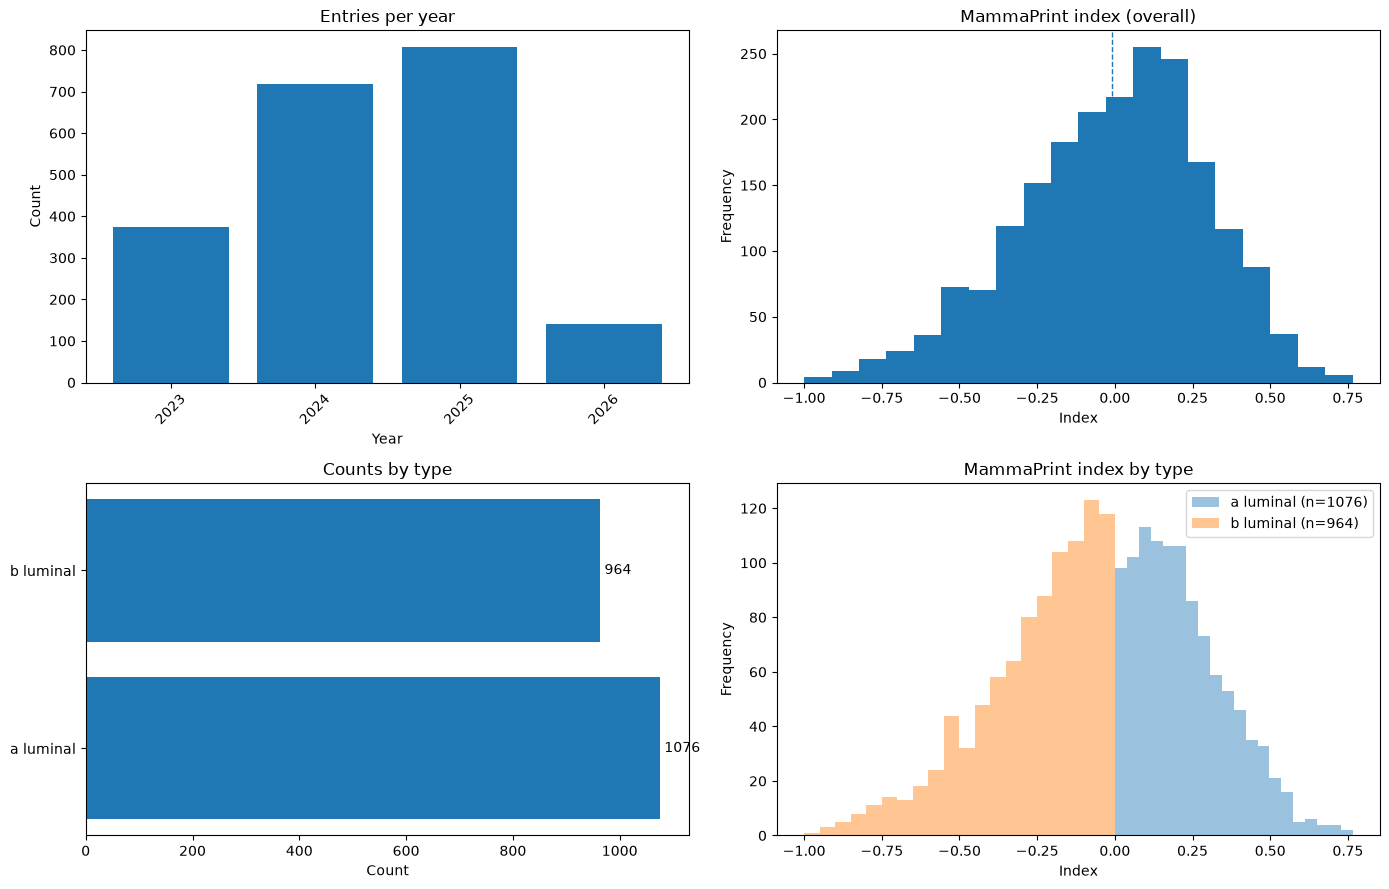

{'per_year': {'counts': record_num
  2023    374
  2024    718
  2025    807
  2026    141
  Name: count, dtype: int64,
  'total': 2040},
 'mammaprint_overall': {'series': 1      -0.158
  2       0.058
  3      -0.039
  4       0.065
  5      -0.429
          ...  
  2304   -0.218
  2306   -0.141
  2307    0.192
  2308    0.396
  2309   -0.065
  Name: mammaprint_index, Length: 2040, dtype: float64,
  'mean': -0.007955049019607845,
  'variance': 0.09011929758116484,
  'count': 2040},
 'mammaprint_by_type': {'a luminal': {'series': 2       0.058
   4       0.065
   6       0.451
   7       0.073
   11      0.090
           ...  
   2300    0.169
   2302    0.091
   2303    0.235
   2307    0.192
   2308    0.396
   Name: mammaprint_index, Length: 1076, dtype: float64,
   'mean': 0.22131849442379178,
   'variance': 0.02272628757391718,
   'count': 1076},
  'b luminal': {'series': 1      -0.158
   3      -0.039
   5      -0.429
   8      -0.052
   9      -0.259
           ...  
   2299   -

In [29]:
run_all_stats_and_plot(final_df, "stats")